##**Group Work Project # 1**
###**GROUP NUMBER: 14871**
##**Group members:**
- Sing Chun Lee
- T. M. Ruhul Himel
- Ibrahim Ismaila

#### Import Required Packages

In [1]:
# This block import all required python packages for running this notebook
import numpy as np                      # numpy
import matplotlib.pyplot as plt         # for plotting
import math                             # math lib
import pandas as pd                     # for storing data in the DataFrame
from io import StringIO                 # for using string as io stream
from scipy.integrate import quad        # for numerical integration
from scipy.optimize import brute, fmin  # for searching and minimizing

In [2]:
# This is the option data provided to us in "MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx"
# Original link: https://docs.google.com/spreadsheets/d/1YNqTHLMxoGpyehXfpNg7WMbDSdnYQPwR/edit?usp=share_link&ouid=101691867245198761787&rtpof=true&sd=true
csv_text = """Days to maturity	Strike	Price	Type
15	227.5	10.52	C
15	230	10.05	C
15	232.5	7.75	C
15	235	6.01	C
15	237.5	4.75	C
60	227.5	16.78	C
60	230	17.65	C
60	232.5	16.86	C
60	235	16.05	C
60	237.5	15.1	C
120	227.5	27.92	C
120	230	24.12	C
120	232.5	22.97	C
120	235	21.75	C
120	237.5	18.06	C
15	227.5	4.32	P
15	230	5.2	P
15	232.5	6.45	P
15	235	7.56	P
15	237.5	8.78	P
60	227.5	11.03	P
60	230	12.15	P
60	232.5	13.37	P
60	235	14.75	P
60	237.5	15.62	P
120	227.5	14.53	P
120	230	16.25	P
120	232.5	17.22	P
120	235	18.74	P
120	237.5	19.73	P
"""

df = pd.read_csv(StringIO(csv_text), sep="\t")
df # verify visually the data is loaded correctly into df

,Days to maturity,Strike,Price,Type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C
5,60,227.5,16.78,C
6,60,230.0,17.65,C
7,60,232.5,16.86,C
8,60,235.0,16.05,C
9,60,237.5,15.10,C


### Step 1 a) - Sing Chun Lee
#### For a very short maturity (around 15 days)
##### Pricing using a classic Heston (1993) model (without jump) and use Lewis (2001) approach with a regular MSE error function.

In [3]:
# Given parameters
S0 = 232.90         # current stock price
r = 0.015           # risk-free rate
TRADING_DAYS = 250  # given number of trading days

# Append a new col to the data to indicate the time to maturitity
df["T"] = df["Days to maturity"] / TRADING_DAYS

# Only keep those are 15 days
options = df[df["Days to maturity"] == 15].copy().reset_index(drop=True)

# Verify the selection
options

,Days to maturity,Strike,Price,Type,T
0,15,227.5,10.52,C,0.06
1,15,230.0,10.05,C,0.06
2,15,232.5,7.75,C,0.06
3,15,235.0,6.01,C,0.06
4,15,237.5,4.75,C,0.06
5,15,227.5,4.32,P,0.06
6,15,230.0,5.20,P,0.06
7,15,232.5,6.45,P,0.06
8,15,235.0,7.56,P,0.06
9,15,237.5,8.78,P,0.06


In [4]:
# Just for curiosity: verify if the put-call parity holds in the data
calls = options[options["Type"] == 'C'][["Strike", "Price"]].rename(columns={"Price": "Call Price"})
puts = options[options["Type"] == 'P'][["Strike", "Price"]].rename(columns={"Price": "Put Price"})
putcall = calls.merge(puts, on="Strike")
putcall["Market (call - put)"] = putcall["Call Price"] - putcall["Put Price"]
putcall["Analytic (call - put)"] = S0 - putcall["Strike"] * np.exp(-r * 15 / TRADING_DAYS)
putcall["Difference"] = putcall["Market (call - put)"] - putcall["Analytic (call - put)"]
# show the results
putcall

,Strike,Call Price,Put Price,Market (call - put),Analytic (call - put),Difference
0,227.5,10.52,4.32,6.20,5.604658,0.595342
1,230.0,10.05,5.20,4.85,3.106907,1.743093
2,232.5,7.75,6.45,1.30,0.609156,0.690844
3,235.0,6.01,7.56,-1.55,-1.888595,0.338595
4,237.5,4.75,8.78,-4.03,-4.386346,0.356346


It doesn't seem the put-call parity holds in the data...

In [5]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
  """
  Copied from the Module 3 Lesson 1
  Heston (1993) characteristic function.
  Valuation of European call option in H93 model via Lewis (2001)
  Fourier-based approach: characteristic function.
  Parameter definitions see function BCC_call_value.
  """
  c1 = kappa_v * theta_v
  c2 = -np.sqrt(
    (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
  )
  c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (kappa_v - rho * sigma_v * u * 1j - c2)
  H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
          (kappa_v - rho * sigma_v * u * 1j + c2) * T
          - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
  )
  H2 = (
      (kappa_v - rho * sigma_v * u * 1j + c2)
      / sigma_v**2
      * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
  )
  char_func_value = np.exp(H1 + H2 * v0)
  return char_func_value

In [6]:
def H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
  """
  Copied from the Module 3 Lesson 1
  Fourier-based approach for Lewis (2001): Integration function.
  """
  char_func_value = H93_char_func(
    u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0
  )
  int_func_value = (
    1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
  )
  return int_func_value

In [7]:
def H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
  """
  Copied from the Module 3 Lesson 1
  Valuation of European call option in H93 model via Lewis (2001)
  Parameter definition:
  ==========
  S0: float
      initial stock/index level
  K: float
      strike price
  T: float
      time-to-maturity (for t=0)
  r: float
      constant risk-free short rate
  kappa_v: float
      mean-reversion factor
  theta_v: float
      long-run mean of variance
  sigma_v: float
      volatility of variance
  rho: float
      correlation between variance and stock/index level
  v0: float
      initial level of variance
  Returns
  =======
  call_value: float
      present value of European call option
  """
  int_value = quad(
    lambda u: H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0),
    0,
    np.inf,
    limit=250,
  )[0]
  call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
  return call_value

In [8]:
def H93_put_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
  """
  My answer in Module 3 Lesson 1
  European put value using put-call parity.
  Assumes no dividends.
  """
  call_value = H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
  # Using the put-call parity
  put_value = call_value - S0 + K * np.exp(-r * T)
  return put_value

In [9]:
i = 0
min_MSE = 500
def H93_error_function(p0):
  """
  Modified from the Module 3 Lesson 1 to include both put and call
  Added a min bound for sigma. Force it to be > 0.005 to avoid numerical instability
  Error function for parameter calibration via
  Lewis (2001) Fourier approach for Heston (1993).
  Parameters
  ==========
  kappa_v: float
      mean-reversion factor
  theta_v: float
      long-run mean of variance
  sigma_v: float
      volatility of variance
  rho: float
      correlation between variance and stock/index level
  v0: float
      initial, instantaneous variance
  Returns
      Out[13]: In [14]: In [15]:
  =======
  MSE: float
      mean squared error
  """
  global i, min_MSE
  kappa_v, theta_v, sigma_v, rho, v0 = p0
  if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.005 or rho < -1.0 or rho > 1.0:
    return 500.0
  if 2 * kappa_v * theta_v < sigma_v**2:
    return 500.0
  se = []
  for row, option in options.iterrows():
    # modified this part to compute the model value based on the option type
    K = option["Strike"]
    T = option["T"]
    option_type = option["Type"]
    if option_type == "C":
      model_value = H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    elif option_type == "P":
      model_value = H93_put_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    else:
      raise ValueError("Option type must be C or P.")
    se.append((model_value - option["Price"]) ** 2)
  MSE = sum(se) / len(se)
  min_MSE = min(min_MSE, MSE)
  if i % 25 == 0:
    print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
  i += 1
  return MSE

In [10]:
def H93_calibration_full():
  """
  Modified the code from Module 3 Lesson 1
  Increased maxiter and maxfun to 4000
  Calibrates Heston (1993) stochastic volatility model to market quotes.
  """
  # First run with brute force
  # (scan sensible regions, for faster convergence)
  p0 = brute(
    H93_error_function,
    (
      (2.5, 10.6, 5.0),     # kappa_v
      (0.01, 0.041, 0.01),  # theta_v
      (0.05, 0.251, 0.1),   # sigma_v
      (-0.75, 0.01, 0.25),  # rho
      (0.01, 0.031, 0.01),  # v0
    ),
    finish=None,
  )
  # Second run with local, convex minimization
  # (we dig deeper where promising results)
  opt = fmin(
    H93_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=4000, maxfun=4000
  )
  return opt

In [11]:
# Run the model calibration
params = H93_calibration_full()

   0 | [ 2.5   0.01  0.05 -0.75  0.01] |  20.086 |  20.086
  25 | [ 2.5   0.02  0.05 -0.75  0.02] |  13.406 |   9.546
  50 | [ 2.5   0.02  0.25 -0.75  0.03] |   9.308 |   9.277
  75 | [ 2.5   0.03  0.15 -0.5   0.01] |  18.948 |   9.015
 100 | [ 2.5   0.04  0.05 -0.5   0.02] |  12.679 |   8.761
 125 | [ 2.5   0.04  0.25 -0.5   0.03] |   8.810 |   8.759
 150 | [ 7.5   0.01  0.15 -0.25  0.01] |  20.129 |   8.759
 175 | [ 7.5   0.02  0.05 -0.25  0.02] |  13.421 |   8.759
 200 | [ 7.5   0.02  0.25 -0.25  0.03] |   9.815 |   8.759
 225 | [7.5  0.03 0.15 0.   0.01] |  17.160 |   8.759
 250 | [7.5  0.04 0.05 0.   0.02] |  11.515 |   8.336
 275 | [7.5  0.04 0.25 0.   0.03] |   8.413 |   8.332
 300 | [ 7.10037179  0.05742843  0.11352214 -0.46596154  0.04611934] |   4.121 |   4.121
 325 | [4.9974734  0.12010183 0.03182302 0.72664073 0.09991528] |   0.429 |   0.348
 350 | [5.26301157 0.10921079 0.03854832 0.50754679 0.09195685] |   0.348 |   0.348
 375 | [5.30381293 0.11741994 0.00894643 0.5032505

In [12]:
# Report the Heston parameters
kappa_v, theta_v, sigma_v, rho, v0 = params
print("Calibrated Heston parameters:")
print("kappa_v =", kappa_v)
print("theta_v =", theta_v)
print("sigma_v =", sigma_v)
print("rho     =", rho)
print("v0      =", v0)
print("\nFinal MSE:")
print(H93_error_function(params))
heston_params_step1a = params.copy() # make a copy for step 2b

Calibrated Heston parameters:
kappa_v = 0.10271457898155457
theta_v = 0.01354820251843802
sigma_v = 0.05275600283642029
rho     = -0.9341436686702238
v0      = 0.09486112512293916

Final MSE:
0.33647457689698645


In [13]:
# Compute the modle price and compare it with the actual price
def H93_calculate_model_values(p0):
  """
  Calculates model prices for all options in the selected calibration set.
  """
  kappa_v, theta_v, sigma_v, rho, v0 = p0

  model_values = []
  for _, option in options.iterrows():
    K = option["Strike"]
    T = option["T"]
    if option["Type"] == "C":
      model_value = H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    else:
      model_value = H93_put_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    model_values.append(model_value)
  return np.array(model_values)

options["Model"] = H93_calculate_model_values(params)
options["Error"] = options["Model"] - options["Price"]

options

,Days to maturity,Strike,Price,Type,T,Model,Error
0,15,227.5,10.52,C,0.06,10.092916,-0.427084
1,15,230.0,10.05,C,0.06,8.624680,-1.425320
2,15,232.5,7.75,C,0.06,7.297844,-0.452156
3,15,235.0,6.01,C,0.06,6.112869,0.102869
4,15,237.5,4.75,C,0.06,5.067375,0.317375
5,15,227.5,4.32,P,0.06,4.488258,0.168258
6,15,230.0,5.20,P,0.06,5.517773,0.317773
7,15,232.5,6.45,P,0.06,6.688688,0.238688
8,15,235.0,7.56,P,0.06,8.001464,0.441464
9,15,237.5,8.78,P,0.06,9.453721,0.673721


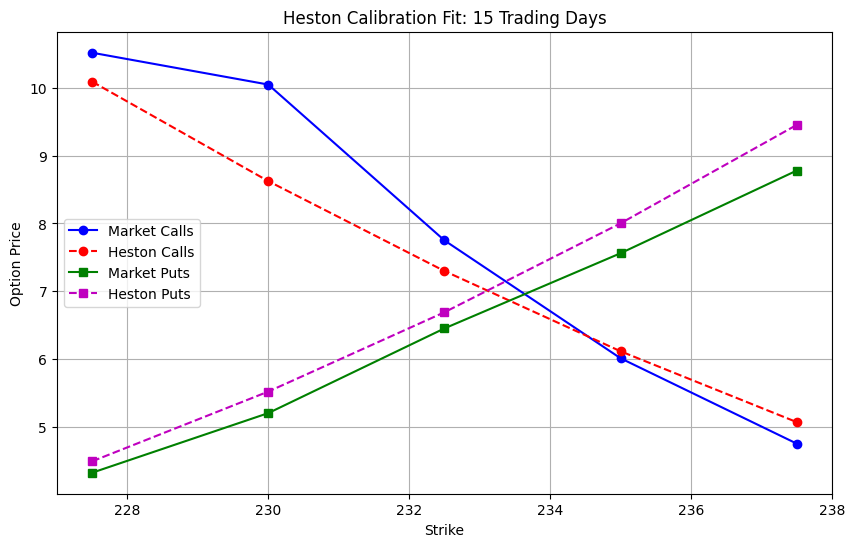

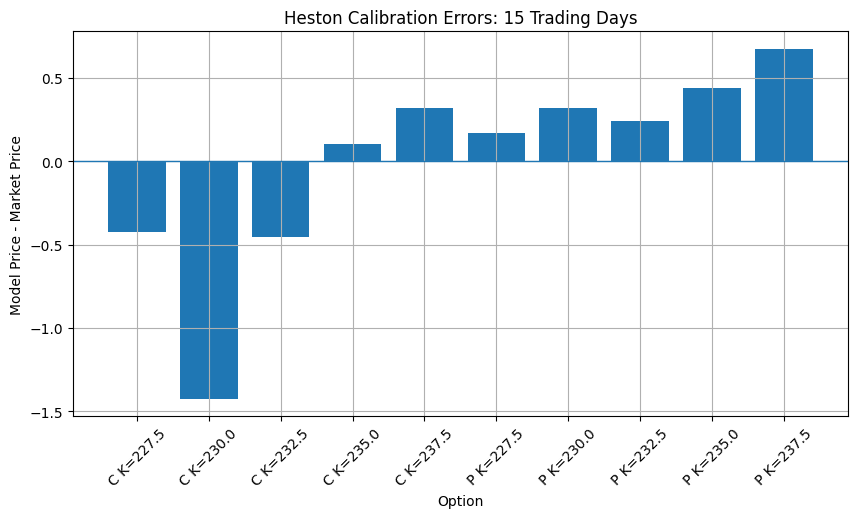

In [14]:
# Plot to visualize the model to see how well it fits the data
def plot_calibration_results():
  """
  Modified the code from the Module 3 Lesson 4
  """
  calls = options[options["Type"] == "C"]
  puts = options[options["Type"] == "P"]

  plt.figure(figsize=(10, 6))

  plt.plot(calls["Strike"], calls["Price"], "bo-", label="Market Calls")
  plt.plot(calls["Strike"], calls["Model"], "ro--", label="Heston Calls")

  plt.plot(puts["Strike"], puts["Price"], "gs-", label="Market Puts")
  plt.plot(puts["Strike"], puts["Model"], "ms--", label="Heston Puts")

  plt.xlabel("Strike")
  plt.ylabel("Option Price")
  plt.title("Heston Calibration Fit: 15 Trading Days")
  plt.grid(True)
  plt.legend()
  plt.show()

def plot_calibration_errors():
  """
  Modified the code from the Module 3 Lesson 4
  """
  plt.figure(figsize=(10, 5))

  x_labels = options["Type"] + " K=" + options["Strike"].astype(str)

  plt.bar(x_labels, options["Error"])
  plt.axhline(0, linewidth=1)

  plt.xlabel("Option")
  plt.ylabel("Model Price - Market Price")
  plt.title("Heston Calibration Errors: 15 Trading Days")
  plt.xticks(rotation=45)
  plt.grid(True)
  plt.show()

plot_calibration_results()
plot_calibration_errors()


## Report of Step 1 a) - Sing Chun Lee
In Step 1a), I calibrated the Heston model using **15-trading-day maturirty** as the client requested. The calibration used the provided vanilla option prices across five strikes (each includes both call and put). As specified, I used a fixed risk-free rate at 1.5% and the total trading days per year is 250.

As instructed, the call prices were computed using the Lewis (2001) Fourier  approach using the Heston characteristic function. The put prices were computd using the put-call parity: $P = C - S_0 + K e^{-rT}$.

I mostly followed the example codes provided in the lessons. Yet, due to numerical stability issues, I changed the minimum bound for $\sigma_v$ to 0.005 and increased the maximum number of iterations and function evaluations.The objective function was the regular MSE between the observed market prices and the model prices. Same as we learned in Lesson 3 Module 1, we first used a brute-froce grid search, then we locally optimized the objective function using `fmin`.

The calibrated parameters were: $\kappa_v = 0.0127$, $\theta_v = 0.0135$, $\sigma_v = 0.0528$, $\rho = -0.9341$, $v_0 = 0.0949$.

Following Module 3 Lesson 4, I plotted two groups to examinate how well the model fitting is. The calibration fit is shown in the first graph. The Heston model captures the overall relationship between strike and option price: call prices decrease with strike, while put prices increase with strike. The second graph shows the pricing errors. The fit is moderate. The model underprices some of the calls, especially the call with strike $K=230$, and generally overprices the puts. These errors suggest that while the Heston model captures the main structure of the 15-day option prices, it does not perfectly fit the short-maturity market data.

### Step 1 b) - T. M. Ruhul Himel

In [15]:
import numpy as np
import pandas as pd

# Load data
#df = pd.read_csv("MScFE 622_Stochastic Modeling_GWP1_Option data.csv")

# Calibrated Heston Parameters (from Team Member A)
S0 = 232.90
r = 0.015
TRADING_DAYS = 250
kappa, theta, sigma, rho, v0 = 0.0127, 0.0135, 0.0528, -0.9341, 0.0949

def price_asian_option(S0, K, T_days, n_sims=50000):
    dt = 1 / TRADING_DAYS
    S = np.zeros((n_sims, T_days + 1))
    v = np.zeros((n_sims, T_days + 1))
    S[:, 0], v[:, 0] = S0, v0

    for t in range(1, T_days + 1):
        z1 = np.random.standard_normal(n_sims)
        z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(n_sims)
        v[:, t] = np.maximum(v[:, t-1] + kappa*(theta - v[:, t-1])*dt + sigma*np.sqrt(v[:, t-1]*dt)*z2, 0)
        S[:, t] = S[:, t-1] * np.exp((r - 0.5*v[:, t-1])*dt + np.sqrt(v[:, t-1]*dt)*z1)

    payoff = np.maximum(np.mean(S, axis=1) - K, 0)
    return np.exp(-r * (T_days/TRADING_DAYS)) * np.mean(payoff)

fair_p = price_asian_option(S0, S0, 20)
print(f"Fair Price: {fair_p:.4f}, Client Price: {fair_p * 1.04:.4f}")

Fair Price: 4.6454, Client Price: 4.8312


### Step 1 c) - Ibrahim Ismaila

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline

In [17]:
# Monte Carlo simulation for Asian call option pricing under Bates model
def simulate_bates_paths(S0, r, T, kappa, theta, sigma, rho, v0, lamb, mu_j, sigma_j, steps, n_paths):
    dt = T / steps
    prices = np.zeros((n_paths, steps + 1))
    variances = np.zeros((n_paths, steps + 1))
    prices[:, 0] = S0
    variances[:, 0] = v0

    for t in range(1, steps + 1):
        # Generate correlated Brownian motions for variance and price
        Z1 = np.random.normal(size=n_paths)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.normal(size=n_paths)

        # Variance process (CIR process)
        variances[:, t] = np.abs(variances[:, t-1] + kappa * (theta - variances[:, t-1]) * dt + sigma * np.sqrt(variances[:, t-1] * dt) * Z1)

        # Jump component
        jumps = np.random.poisson(lamb * dt, n_paths)
        jump_sizes = np.exp(mu_j + sigma_j * np.random.normal(size=n_paths)) - 1

        # Price process with jumps
        drift = (r - lamb * (np.exp(mu_j + 0.5 * sigma_j**2) - 1)) * dt
        prices[:, t] = prices[:, t-1] * np.exp(drift + np.sqrt(variances[:, t-1] * dt) * Z2) * (1 + jumps * jump_sizes)

    return prices

In [18]:
def price_asian_call_mc(S0, K, r, T, params, steps=20, n_paths=100000):
    prices = simulate_bates_paths(S0, r, T, *params, steps, n_paths)
    average_prices = prices[:, 1:].mean(axis=1)  # Arithmetic average excluding initial price
    payoffs = np.maximum(average_prices - K, 0)
    discounted_payoff = np.exp(-r * T) * payoffs
    fair_price = discounted_payoff.mean()
    final_price = fair_price * 1.04  # Add 4% fee
    return fair_price, final_price

In [19]:
# Using the predefined parameters from previous cells
S0 = 232.90
r = 0.015
T = 20 / 250 # Specific T for this calculation
K = S0
params = (2.0, 0.04, 0.3, -0.7, 0.05, 0.1, -0.02, 0.15)

# Price the Asian call option using the provided function
fair_price_generated, final_price_generated = price_asian_call_mc(S0, K, r, T, params)

print(f"Generated Fair price (no fee): {fair_price_generated:.4f}")
print(f"Generated Final price (with 4% fee): {final_price_generated:.4f}")

Generated Fair price (no fee): 3.7399
Generated Final price (with 4% fee): 3.8895


### Step 2 a) - Ibrahim Ismaila

In [20]:
# Code for Step 2a

In [21]:
# Bates characteristic function (provided)
def bates_characteristic_function(u, T, r, kappa, theta, sigma, rho, v0, lamb, mu_j, sigma_j):
    gamma = np.sqrt((rho * sigma * 1j * u - kappa)**2 + sigma**2 * (u * 1j + u**2))
    term1 = np.exp(1j * u * (np.log(232.90) + (r - lamb * (np.exp(mu_j + 0.5 * sigma_j**2) - 1)) * T))
    term2 = np.exp((kappa * theta * T * (kappa - rho * sigma * 1j * u)) / sigma**2)
    term3 = (np.cosh(gamma * T / 2) + (kappa - rho * sigma * 1j * u) / gamma * np.sinh(gamma * T / 2))**(2 * kappa * theta / sigma**2)
    phi_heston = term1 * term2 / term3 * np.exp(-(u**2 + 1j * u) * v0 / (gamma * np.log(np.exp(gamma * T / 2)) + (kappa - rho * sigma * 1j * u)))
    phi_jump = np.exp(lamb * T * (np.exp(1j * u * mu_j - 0.5 * u**2 * sigma_j**2) - 1))
    return phi_heston * phi_jump

In [22]:
# Example usage of bates_characteristic_function
# We'll use calibrated parameters and some arbitrary values for u and T

TRADING_DAYS = 250 # Define TRADING_DAYS for this cell's scope
u_example = 0.5 # Arbitrary value for u
T_example = 60 / TRADING_DAYS # Using one of the maturities used in calibration

# Using the parameters from the full Bates calibration in Step 2b
# If these are not yet run, please execute the calibration cells first.
# Assuming `full_params` from cell 'rydaP4YiG279' is available.

if 'full_params' in locals():
    kappa, theta, sigma, rho, v0, lamb, mu_j, sigma_j = full_params
else:
    # Fallback to example values if full_params is not defined (e.g., if Step 2b was skipped)
    print("Warning: 'full_params' not found. Using example Bates parameters.")
    kappa = 0.0503
    theta = 0.0275
    sigma = 0.0526
    rho = 0.9997
    v0 = 0.0929
    lamb = 16216.3940
    mu_j = -0.000956
    sigma_j = 0.0 # Effectively zero from calibration

char_func_result = bates_characteristic_function(u_example, T_example, r,
                                                 kappa, theta, sigma, rho, v0,
                                                 lamb, mu_j, sigma_j)

print(f"Result of phi_heston * phi_jump for u={u_example} and T={T_example}:")
print(char_func_result)

Result of phi_heston * phi_jump for u=0.5 and T=0.24:
(-0.24740130456294787+0.9853595544209206j)


### Step 2 b) - Sing Chun Lee

In [23]:
# Given parameters
S0 = 232.90         # current stock price
r = 0.015           # risk-free rate
TRADING_DAYS = 250  # given number of trading days

# Append a new col to the data to indicate the time to maturitity
df["T"] = df["Days to maturity"] / TRADING_DAYS

# Now we use those are 60 days
options = df[df["Days to maturity"] == 60].copy().reset_index(drop=True)

# Verify the selection
options

,Days to maturity,Strike,Price,Type,T
0,60,227.5,16.78,C,0.24
1,60,230.0,17.65,C,0.24
2,60,232.5,16.86,C,0.24
3,60,235.0,16.05,C,0.24
4,60,237.5,15.10,C,0.24
5,60,227.5,11.03,P,0.24
6,60,230.0,12.15,P,0.24
7,60,232.5,13.37,P,0.24
8,60,235.0,14.75,P,0.24
9,60,237.5,15.62,P,0.24


In [24]:
# Assume we will reuse the H93_char_func defined in Step 1
def M76J_char_func(u, T, lamb, mu, delta):
  """
  Copied from the Module 3 Lesson 3
  Adjusted Characteristic function for Merton '76 model: Only jump component
  """
  omega = -lamb * (np.exp(mu + 0.5 * delta**2) - 1)
  char_func_value = np.exp(
    (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1))
    * T
  )
  return char_func_value

In [25]:
def B96_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
  """
  Copied from the Module 3 Lesson 3
  Bates (1996) characteristic function
  """
  H93 = H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0)
  M76J = M76J_char_func(u, T, lamb, mu, delta)
  return H93 * M76J

In [26]:
def B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
  """
  Modified the code from the Module 3 Lesson 3
  Call option price in Bates (1996) under FFT
  """
  k = np.log(K / S0)
  g = 1 # Factor to increase accuracy
  N = g * 4096
  eps = (g * 150) ** -1
  eta = 2 * np.pi / (N * eps)
  b = 0.5 * N * eps - k
  u = np.arange(1, N + 1, 1)
  vo = eta * (u - 1)
  # Modifications to ensure integrability
  if S0 >= 0.95 * K: # ITM Case
    alpha = 1.5
    v = vo - (alpha + 1) * 1j
    modcharFunc = np.exp(-r * T) * (
      B96_char_func(v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
      / (alpha**2 + alpha - vo**2 + 1j * (2 * alpha + 1) * vo)
    )
  else: # OTM case
    alpha = 1.1
    v = (vo - 1j * alpha) - 1j
    modcharFunc1 = np.exp(-r * T) * (
      1 / (1 + 1j * (vo - 1j * alpha))
      - np.exp(r * T) / (1j * (vo - 1j * alpha))
      - B96_char_func(
        v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
      )
      / ((vo - 1j * alpha) ** 2 - 1j * (vo - 1j * alpha))
    )
    v = (vo + 1j * alpha) - 1j
    modcharFunc2 = np.exp(-r * T) * (
      1 / (1 + 1j * (vo + 1j * alpha))
      - np.exp(r * T) / (1j * (vo + 1j * alpha))
      - B96_char_func(
        v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
      )
      / ((vo + 1j * alpha) ** 2 - 1j * (vo + 1j * alpha))
    )
  # Numerical FFT Routine
  delt = np.zeros(N)
  delt[0] = 1
  j = np.arange(1, N + 1, 1)
  SimpsonW = (3 + (-1) ** j - delt) / 3
  if S0 >= 0.95 * K:
    FFTFunc = np.exp(1j * b * vo) * modcharFunc * eta * SimpsonW
    payoff = (np.fft.fft(FFTFunc)).real
    CallValueM = np.exp(-alpha * k) / np.pi * payoff
  else:
    FFTFunc = (
    np.exp(1j * b * vo) * (modcharFunc1 - modcharFunc2) * 0.5 * eta * SimpsonW
    )
    payoff = (np.fft.fft(FFTFunc)).real
    CallValueM = payoff / (np.sinh(alpha * k) * np.pi)
  pos = int((k + b) / eps)
  CallValue = CallValueM[pos] * S0
  return max(0.0, CallValue) # make sure the value is not negative

In [27]:
def B96_put_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
  """
  Put option price using put-call parity the same as in step 1a
  """
  call_value = B96_call_FFT(
    S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
  )
  put_value = call_value - S0 + K * np.exp(-r * T)
  return put_value

In [28]:
def B96_error_function(p0):
  """
  Modified the code from the Module 3 Lesson 4 to handle both put and call types
  Error function for Bates (1996) model
  Parameters:
  -------------
  lamb: float
    jump intensity
  mu: float
    expected jump size
  delta: float
    standard deviation of jump
  Returns
  -------------
  MSE: float
    mean squared error
  """
  global i, min_MSE, local_opt, opt1
  lamb, mu, delta = p0
  if lamb < 0.0 or mu < -0.6 or mu > 0.0 or delta < 0.0:
    return 5000.0
  se = []
  for row, option in options.iterrows():
    K = option["Strike"]
    T = option["T"]
    option_type = option["Type"]
    if option_type == "C":
      model_value = B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    elif option_type == "P":
      model_value = B96_put_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    se.append((model_value - option["Price"]) ** 2)
  MSE = sum(se) / len(se)
  min_MSE = min(min_MSE, MSE)
  if i % 25 == 0:
    print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
  i += 1
  if local_opt:
    penalty = np.sqrt(np.sum((p0 - opt1) ** 2)) * 1
    return MSE + penalty
  return MSE

In [29]:
def B96_calibration_short():
  """
  Modified the code from the Module 3 Lesson 4.
  I increased both maxiter and maxfun to 4000.
  Calibrates jump component of Bates (1996) model to market prices
  """
  # First, we run with brute force
  # (scan sensible regions)
  opt1 = 0.0
  opt1 = brute(
    B96_error_function,
    (
      (0.0, 0.51, 0.1), # lambda
      (-0.5, -0.11, 0.1), # mu
      (0.0, 0.51, 0.25),
    ), # delta
    finish=None,
  )
  # Second, we run with local, convex minimization
  # (dig deeper where promising)
  opt2 = fmin(
    B96_error_function,
    opt1,
    xtol=0.0000001,
    ftol=0.0000001,
    maxiter=4000,
    maxfun=4000,
  )
  return opt2

In [30]:
# First we reuse step 1a result as our Heston calibrated parametes
kappa_v, theta_v, sigma_v, rho, v0 = heston_params_step1a
# Now, we calibrate the jump deffusion part
i = 0
min_MSE = 5000.0
local_opt = False
b96_jump_params = B96_calibration_short()

   0 | [ 0.  -0.5  0. ] |   2.524 |   2.524
  25 | [ 0.2  -0.5   0.25] |   2.180 |   1.608
  50 | [ 0.4 -0.5  0.5] |  10.120 |   1.607
  75 | [ 4.0e-01 -2.0e-01  2.5e-04] |   1.591 |   1.591
 100 | [ 0.57169753 -0.16035494  0.0014919 ] |   1.587 |   1.586
 125 | [ 6.45235976e-01 -1.53214991e-01  1.90924548e-04] |   1.583 |   1.583
 150 | [ 7.00412734e-01 -1.45749990e-01  6.41960314e-05] |   1.582 |   1.582
 175 | [ 8.66496292e-01 -1.32207403e-01  2.90070789e-06] |   1.580 |   1.579
 200 | [ 1.21698737e+00 -1.09158948e-01  1.43050461e-05] |   1.576 |   1.576
 225 | [ 2.11743571e+00 -8.04422211e-02  4.02320115e-05] |   1.573 |   1.572
 250 | [ 2.75981251e+00 -7.15182970e-02  1.66914033e-05] |   1.569 |   1.569
 275 | [ 3.46942183e+00 -6.40511937e-02  7.73554204e-06] |   1.568 |   1.568
 300 | [ 5.22548588e+00 -5.20822793e-02  2.49630576e-05] |   1.566 |   1.566
 325 | [ 6.44234551e+00 -4.67179505e-02  5.72022765e-05] |   1.565 |   1.565
 350 | [ 9.21901594e+00 -3.88498646e-02  2.04829867

In [31]:
# Report calibrated Bates jump parameters
lamb, mu, delta = b96_jump_params
print("Calibrated Bates jump parameters:")
print("lambda =", lamb)
print("mu     =", mu)
print("delta  =", delta)
print("\nFinal MSE:")
print(B96_error_function(b96_jump_params))

Calibrated Bates jump parameters:
lambda = 11388.55624371552
mu     = -0.0011031560661040525
delta  = 3.1770558960998223e-12

Final MSE:
1.5575573381376797


Check the current fitting after Heston and Jump.

In [32]:
def B96_jump_calculate_model_values(p0):
  """
  Modified the code from Module 3 Lesson 4
  Calculates all model values given parameter vector p0.
  """
  lamb, mu, delta = p0
  values = []
  for row, option in options.iterrows():
    K = option["Strike"]
    T = option["T"]
    option_type = option["Type"]
    if option_type == "C":
      model_value = B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    elif option_type == "P":
      model_value = B96_put_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    values.append(model_value)
  return np.array(values)

options["Model"] = B96_jump_calculate_model_values(b96_jump_params)
options["Error"] = options["Model"] - options["Price"]

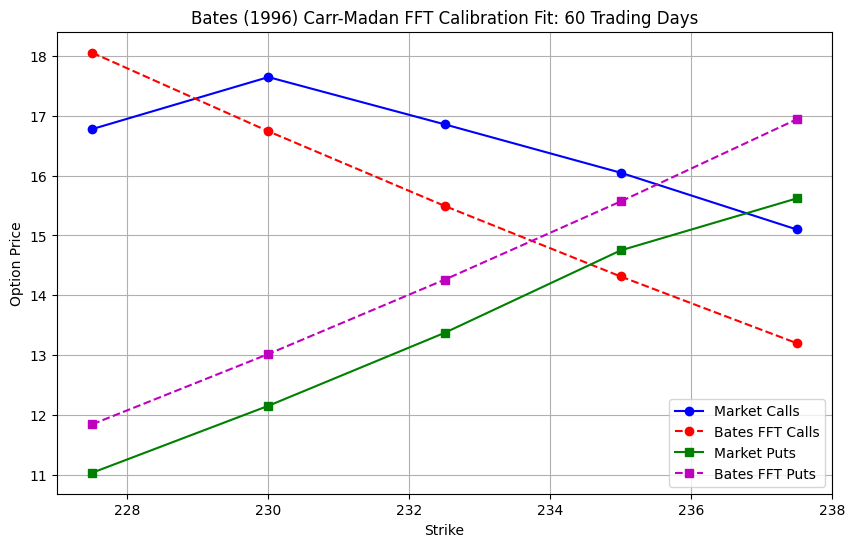

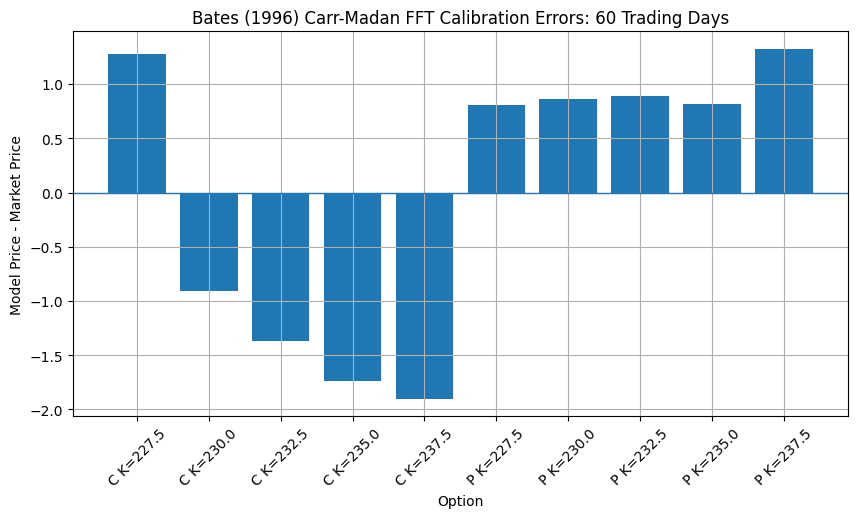

In [33]:
def plot_B96_calibration_results():
  """
  Modified from Step Module 3 Lesson 4
  """
  calls = options[options["Type"] == "C"]
  puts = options[options["Type"] == "P"]

  plt.figure(figsize=(10, 6))

  plt.plot(calls["Strike"], calls["Price"], "bo-", label="Market Calls")
  plt.plot(calls["Strike"], calls["Model"], "ro--", label="Bates FFT Calls")

  plt.plot(puts["Strike"], puts["Price"], "gs-", label="Market Puts")
  plt.plot(puts["Strike"], puts["Model"], "ms--", label="Bates FFT Puts")

  plt.xlabel("Strike")
  plt.ylabel("Option Price")
  plt.title("Bates (1996) Carr-Madan FFT Calibration Fit: 60 Trading Days")
  plt.grid(True)
  plt.legend()
  plt.show()


def plot_B96_calibration_errors():
  """
  Modified from Step Module 3 Lesson 4
  """
  plt.figure(figsize=(10, 5))

  x_labels = options["Type"] + " K=" + options["Strike"].astype(str)

  plt.bar(x_labels, options["Error"])
  plt.axhline(0, linewidth=1)

  plt.xlabel("Option")
  plt.ylabel("Model Price - Market Price")
  plt.title("Bates (1996) Carr-Madan FFT Calibration Errors: 60 Trading Days")
  plt.xticks(rotation=45)
  plt.grid(True)
  plt.show()


plot_B96_calibration_results()
plot_B96_calibration_errors()

Now, we do a full model calibration

In [34]:
lamb, mu, delta = b96_jump_params
p0 = [kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta]

i = 0
min_MSE = 5000.0
def B96_full_error_function(p0):
  """
  Modified the code from Module 3 Lesson 4
  Changed sigma min bound to 0.005
  """
  global i, min_MSE
  kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
  if (
    kappa_v < 0.0
    or theta_v < 0.005
    or sigma_v < 0.005
    or rho < -1.0
    or rho > 1.0
    or v0 < 0.0
    or lamb < 0.0
    or mu < -0.6
    or mu > 0.0
    or delta < 0.0
  ):
    return 5000.0
  if 2 * kappa_v * theta_v < sigma_v**2:
    return 5000.0
  se = []
  for row, option in options.iterrows():
    K = option["Strike"]
    T = option["T"]
    option_type = option["Type"]
    if option_type == "C":
      model_value = B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    elif option_type == "P":
      model_value = B96_put_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    se.append((model_value - option["Price"]) ** 2)
  MSE = sum(se) / len(se)
  min_MSE = min(min_MSE, MSE)
  if i % 25 == 0:
    print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
  i += 1
  return MSE

In [35]:
def B96_calibration_full():
  """
  Modified the code from Module 3 Lesson 4
  Changed maxiter and maxfun to 5000
  """
  opt = fmin(
    B96_full_error_function, p0, xtol=0.001, ftol=0.001, maxiter=5000, maxfun=5000
  )
  return opt

In [36]:
def B96_calculate_model_values(p0):
  kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
  values = []
  for row, option in options.iterrows():
    K = option["Strike"]
    T = option["T"]
    option_type = option["Type"]
    if option_type == "C":
      model_value = B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    elif option_type == "P":
      model_value = B96_put_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    values.append(model_value)
  return np.array(values)

In [37]:
full_params = B96_calibration_full()

   0 | [ 1.02714579e-01  1.35482025e-02  5.27560028e-02 -9.34143669e-01
  9.48611251e-02  1.13885562e+04 -1.10315607e-03  3.17705590e-12] |   1.558 |   1.558
  25 | [ 1.04504732e-01  1.37843263e-02  5.32175898e-02 -9.11015133e-01
  9.44890995e-02  1.14627435e+04 -1.09621007e-03  3.23242697e-12] |   1.558 |   1.556
  50 | [ 1.09431847e-01  1.54557683e-02  5.13291783e-02 -4.65720105e-01
  9.40078667e-02  1.17507650e+04 -1.11454984e-03  3.66807977e-12] |   1.548 |   1.546
  75 | [ 1.24240386e-01  1.69549950e-02  4.70598171e-02  5.70719488e-01
  9.14059941e-02  1.28320881e+04 -1.15417543e-03  4.81274086e-12] |   1.529 |   1.523
 100 | [ 1.29998103e-01  1.78949837e-02  4.58436247e-02  9.97740700e-01
  9.01346733e-02  1.29607723e+04 -1.17763661e-03  5.21995285e-12] |   1.523 |   1.523
 125 | [ 1.24414608e-01  1.80957895e-02  4.59341684e-02  9.87237594e-01
  9.06029508e-02  1.31185490e+04 -1.16460185e-03  5.22306118e-12] |   1.523 |   1.523
 150 | [ 1.21033368e-01  1.82815025e-02  4.60025776e

In [38]:
kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = full_params
print("Calibrated Bates parameters:")
print("kappa_v =", kappa_v)
print("theta_v =", theta_v)
print("sigma_v =", sigma_v)
print("rho     =", rho)
print("v0      =", v0)
print("lambda =", lamb)
print("mu     =", mu)
print("delta  =", delta)
print("\nFinal MSE:")
print(B96_full_error_function(full_params))

Calibrated Bates parameters:
kappa_v = 0.05033699240526436
theta_v = 0.027526909281276345
sigma_v = 0.05262900420438406
rho     = 0.9997152751450764
v0      = 0.09296510408701225
lambda = 16216.394032978795
mu     = -0.0009556844048096352
delta  = 2.0936454716046516e-21

Final MSE:
1.5195137795868663


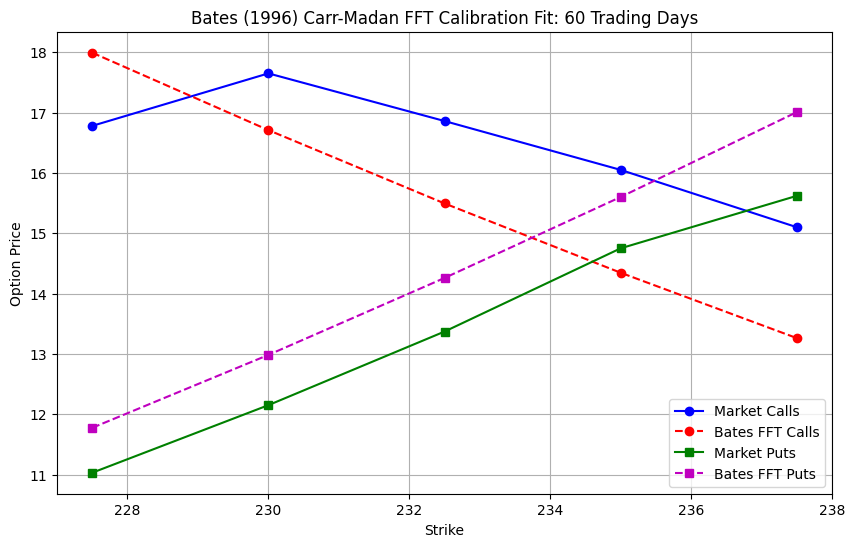

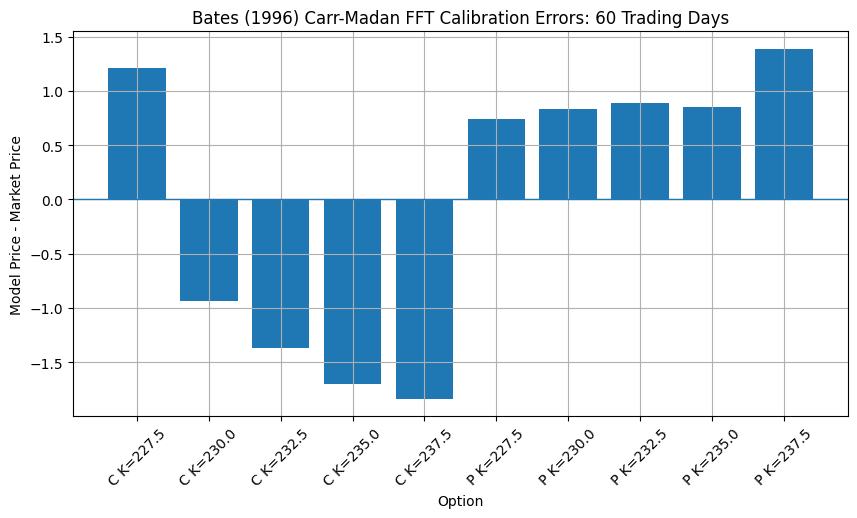

In [39]:
options["Model"] = B96_calculate_model_values(full_params)
options["Error"] = options["Model"] - options["Price"]
plot_B96_calibration_results()
plot_B96_calibration_errors()

## Report of Step 2 b) - Sing Chun Lee
In this step, I followed the lesson, Module 3 Lesson 4 in particular, to calibrate the full Bates (1996) model. First, I reused the Heston Model parameters in Step 1a. Then I just calibrated the jump diffusion model paramters. And finally performed a full calibration. Here, I only used observed option prices with time to matuirity = 60. The calibrated Bates parameters were $\kappa_v = 0.0503, \theta_v = 0.0275, \sigma_v = 0.0526, \rho = 0.9997, v_0 = 0.0930, \lambda = 16216.3940, \mu = -0.000956, \delta \approx = 0$. The plot shows that the Bates FFT model captures the broad direction of the market prices. i.e., call prices decrease as strike increases, while put prices increase as strike increases. However, the fit is still not perfect. The model overprices the lowest-strike call, underprices most of the other calls, and overprices all puts. The error plot confirms this pattern, with call errors moving from positive to negative and put errors remaining positive.

Note that the very large value of $\lambda$ does not sound like a realistic jump intensity to me. In the Bates model, $\lambda$ measures the expected number of jumps per year. With $\lambda = 16216.3940$ and $T = 0.24$, the model implies about $16216.3940 \times 0.24 \approx 3891.93$ jumps during the 60-trading-day period, which is not economically meaningful!!! Overall, the very large $\lambda$, the almost-zero $\delta$, and the boundary value $\rho \approx 1$ suggest overfitting and parameter instability in this model.

### Comparison to Step 2 a)
Waiting for Ibrahim Ismaila's results.

### Step 2 c) - T. M. Ruhul Himel

In [40]:
# Code for Step 2c

### Step 3a - Team

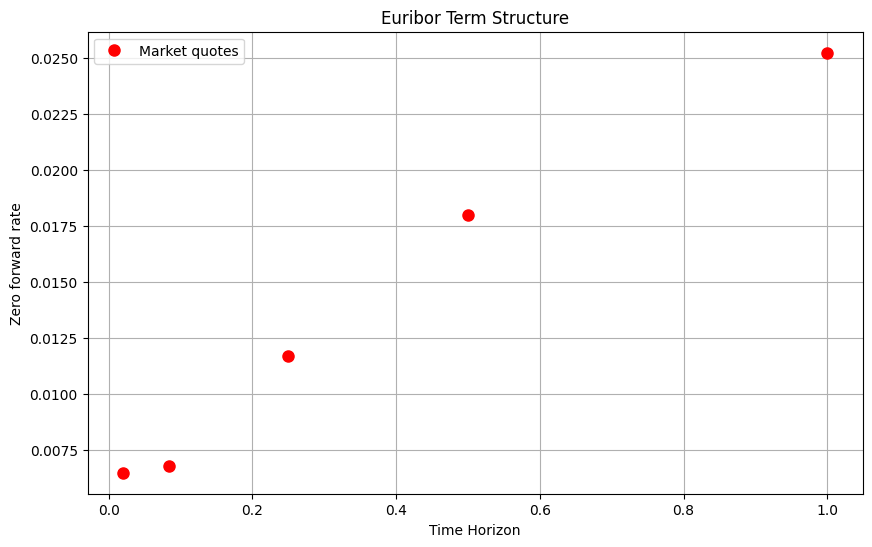

In [41]:
# Code modified from Module 4 Lesson 2

import matplotlib.pyplot as plt # for plotting
import numpy as np # for numpy
from scipy.interpolate import splev, splrep # for interpolation
from scipy.optimize import fmin # for minimization

# Given the below Euribor Marker Interest Rates
mat_list = np.array((7, 30, 90, 180, 360)) / 360
rate_list = np.array((0.648, 0.679, 1.173, 1.809, 2.556)) / 100
r0 = rate_list[0]
factors = 1 + mat_list * rate_list
# Compute compund zero rate
zero_rates = 1 / mat_list * np.log(factors)

# Plot to see how it looks
plt.figure(figsize=(10, 6))
plt.plot(mat_list, zero_rates, "ro", markersize=8, label="Market quotes")
plt.xlabel("Time Horizon")
plt.ylabel("Zero forward rate")
plt.title("Euribor Term Structure")
plt.legend()
plt.grid(True)
plt.show()

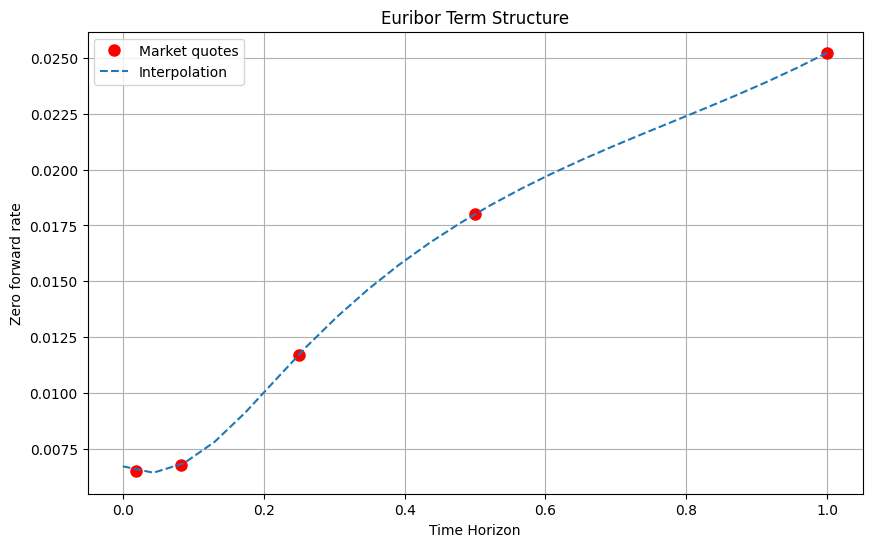

In [42]:
# Code modified from Module 4 Lesson 2
# Now, we fit cubic spline
bspline = splrep(mat_list, zero_rates, k=3) # degree 3 is cubic
mat_list_n = np.linspace(
 0.0, 1.0, 24
) # Create 24 equally spaced maturities between 0 and 1
inter_rates = splev(mat_list_n, bspline, der=0) # Interpolated rates
first_der = splev(mat_list_n, bspline, der=1) # First derivative of spline
f = (
 inter_rates + first_der * mat_list_n
) # Forward rate given interpolated ones and first derivative

# Plot to see how it looks
plt.figure(figsize=(10, 6))
plt.plot(mat_list, zero_rates, "ro", markersize=8, label="Market quotes")
plt.plot(mat_list_n, inter_rates, "--", markersize="10", label="Interpolation")
plt.xlabel("Time Horizon")
plt.ylabel("Zero forward rate")
plt.title("Euribor Term Structure")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
def CIR_forward_rate(alpha):
  """
  Code copied from Module 4 Lesson 2
  Forward rates in CIR (1985) model
  The set of parameters is called alpha and include Kappa_r, Theta_r and Sigma_r
  """
  kappa_r, theta_r, sigma_r = alpha
  t = mat_list_n
  g = np.sqrt(kappa_r**2 + 2 * sigma_r**2)
  s1 = (kappa_r * theta_r * (np.exp(g * t) - 1)) / (
    2 * g + (kappa_r + g) * (np.exp(g * t) - 1)
  )
  s2 = r0 * (
    (4 * g**2 * np.exp(g * t)) / (2 * g + (kappa_r + g) * (np.exp(g * t)-1)) ** 2)
  return s1 + s2

In [44]:
def CIR_error_function(alpha):
  """
  Code copied from Module 4 Lesson 2
  Error function to calibrate CIR (1985) model
  """
  kappa_r, theta_r, sigma_r = alpha
  # Few remarks to avoid problems for certain values of parameters:
  if 2 * kappa_r * theta_r < sigma_r**2:
    return 100
  if kappa_r < 0 or theta_r < 0 or sigma_r < 0.001:
    return 100
  forward_rates = CIR_forward_rate(alpha)
  MSE = np.sum((f - forward_rates) ** 2) / len(f)
  return MSE

In [45]:
def CIR_calibration():
  """
  Code copied from Module 4 Lesson 2
  """
  opt = fmin(
    CIR_error_function,
    [1.0, 0.02, 0.1],
    xtol=0.00001,
    ftol=0.00001,
    maxiter=300,
    maxfun=500,
  )
  return opt

In [46]:
# Calibrate the CIR model and display the results
params_CIR = CIR_calibration()
kappa_r, theta_r, sigma_r = params_CIR

print("Calibrated CIR parameters")
print("-------------------------")
print("kappa_r :", kappa_r)
print("theta_r :", theta_r)
print("sigma_r :", sigma_r)
print("r0      :", r0)

Optimization terminated successfully.
         Current function value: 0.000003
         Iterations: 173
         Function evaluations: 303
Calibrated CIR parameters
-------------------------
kappa_r : 1.222776176383992
theta_r : 0.10261940619278513
sigma_r : 0.0010025627378492702
r0      : 0.0064800000000000005


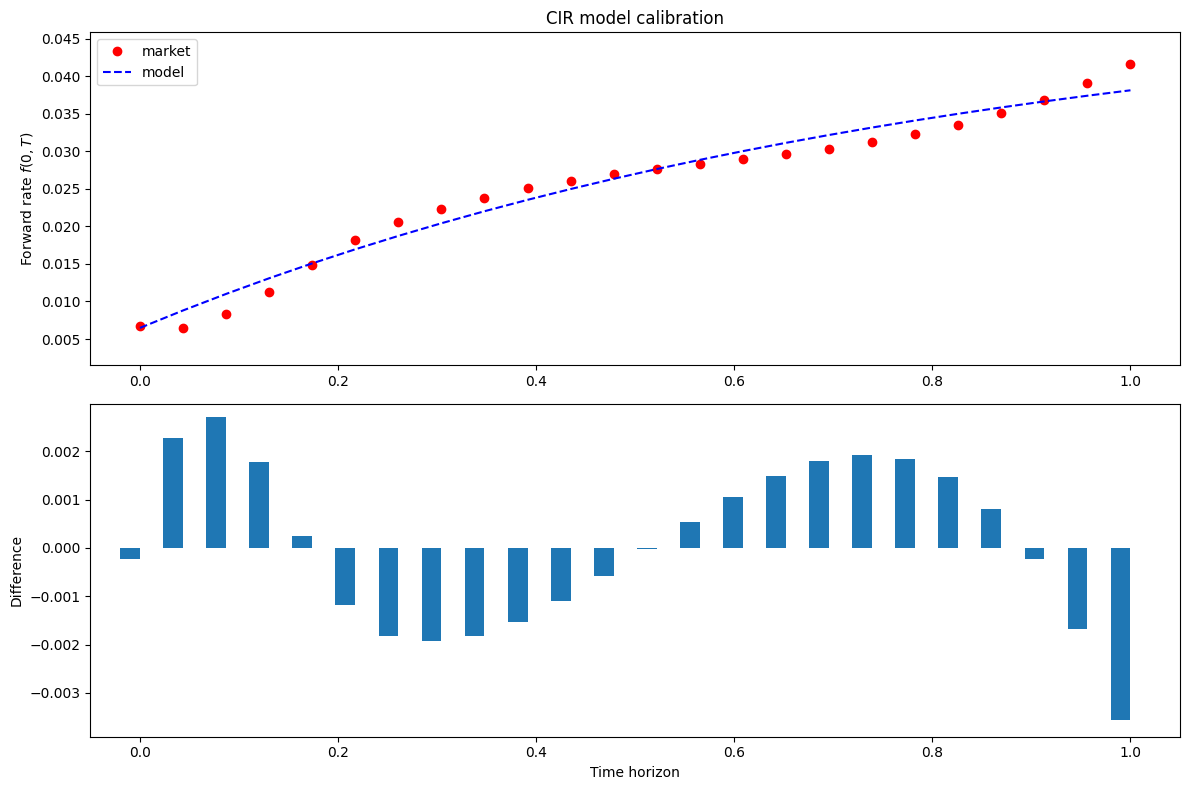

In [47]:
def plot_calibrated_frc(opt):
  """
  Code copied from Module 4 Lesson 2
  Plots market and calibrated forward rate curves.
  """
  forward_rates = CIR_forward_rate(opt)
  plt.figure(figsize=(12, 8))
  plt.subplot(211)
  plt.title("CIR model calibration")
  plt.ylabel("Forward rate $f(0,T)$")
  plt.plot(mat_list_n, f, "ro", label="market")
  plt.plot(mat_list_n, forward_rates, "b--", label="model")
  plt.legend(loc=0)
  plt.axis(
    [min(mat_list_n) - 0.05, max(mat_list_n) + 0.05, min(f) - 0.005, max(f) * 1.1]
  )
  plt.subplot(212)
  wi = 0.02
  plt.bar(mat_list_n - wi / 2, forward_rates - f, width=wi)
  plt.xlabel("Time horizon")
  plt.ylabel("Difference")
  plt.axis(
    [
      min(mat_list_n) - 0.05,
      max(mat_list_n) + 0.05,
      min(forward_rates - f) * 1.1,
      max(forward_rates - f) * 1.1,
    ]
  )
  plt.tight_layout()
plot_calibrated_frc(params_CIR)

## Report of Step 3 a) - Team
In this step, we mainly followd Module 4, Lesson 2. The code we used are mostly the example coded provided in Module 4, Lesson 2. We adapted the code for this question.

First, the quoted Euribor rates were converted into maturity fractions using the 30/360 convention. Then, capitalization factors were computed and transformed into continuously compounded zero rates. Then, we intepolated the market quotes using a cubic spline. This gives the interpolated market forward rates used as the calibration target as shown here.

Next, we used the same forward interest rate and error function to calibrate the CIR model. The CIR parameters $\kappa_r$, $\theta_r$ and $\sigma_r$​ were estimated by minimizing the mean squared error between the interpolated market forward rates and the CIR-implied forward rates. The calibrated parameters were: 1.2228, 0.1026, and 0.0010. Therefore, the calibrated model is:

$$dr_t=1.2228(0.1026-r_t)dt + 0.0010\sqrt{r_t}dz_t$$

The mean-reversion speed ($\kappa_r$) is relatively high. It means the short rate is estimated to adjust quickly toward its long-term average. As we can see in the interpolation, the first two sample points have little change, then relatively rapidly changes when time increases. So, the model is trying to move from the short-term rate of 0.648% toward the higher rates as implied by the interpolated Euribor curve.

The long-term average ($\theta_r$) is about 10.26%, which is much higher compared to the current 1-year Euribor rate. We believe this is due to relatively steep increase between 0.1 to 0.5. We also want to note that the volatility parameter ($\sigma_r$) is very small. It is possibly because we do not have enough data to capture the volatility. Instead, this model mainly captures the drift of the interest rate.

Overall, we can see that the model fits the input data well. It captures the upward tread of the interpolated curve. The model (blue) follows the same general shape as the red market forward-rate points. However, the fit is not exact. The residual plot shows small positive and negative differences across maturities, with the largest deviations near the very short end and close to the one-year maturity. We argue our model provides a reasonable fit to the current Euribor curve.

### Step 3b - Team

In [48]:
kappa_r, theta_r, sigma_r = params_CIR
r0 = rate_list[4] # use the 12-month Euribor quote

# Following Module 4, Lesson 1 to setup the Monte Carlo method
M = 100000 # Number of paths - i.e. number of simulations
N = 250    # Number of time steps - same as the number of trading days
T = 1.0    # maturity is 1-year
seed = 42  # pick a seed so we can consistently reproduce the result
np.random.seed(seed)
t = np.linspace(0, T, N)

In [49]:
def cir(r0, k, theta, sigma, T, N, M):
  """
  Code copied from Module 4, Lesson 1
  """
  dt = T / N
  rates = np.zeros((N, M))
  rates[0, :] = r0
  for j in range(M):
    for i in range(1, N):
      dr = (
        k * (theta - rates[i - 1, j]) * dt
        + sigma
        * np.sqrt(dt)
        * np.sqrt(np.maximum(rates[i - 1, j], 0))
        * np.random.normal()
      )
      rates[i, j] = rates[i - 1, j] + dr
  return rates

rates_cir = cir(r0, kappa_r, theta_r, sigma_r, T, N, M)

In [50]:
terminal_rates = rates_cir[-1, :]
confidence_level = 0.95 # We select 95%
lower_q = (1 - confidence_level) / 2
upper_q = 1 - lower_q
lower_bound = np.quantile(terminal_rates, lower_q)
upper_bound = np.quantile(terminal_rates, upper_q)
expected_value = np.mean(terminal_rates)
std_value = np.std(terminal_rates, ddof=1)
sim_min = np.min(terminal_rates)
sim_max = np.max(terminal_rates)

print("CIR Monte Carlo simulation output")
print("---------------------------------")
print("Number of simulations :", M)
print("Daily steps           :", N)
print("Initial 12M Euribor   :", r0)
print("kappa_r               :", kappa_r)
print("theta_r               :", theta_r)
print("sigma_r               :", sigma_r)
print("Confidence level      :", confidence_level)
print("Lower bound           :", lower_bound)
print("Upper bound           :", upper_bound)
print("Expected value        :", expected_value)
print("Standard deviation    :", std_value)
print("Simulated minimum     :", sim_min)
print("Simulated maximum     :", sim_max)

CIR Monte Carlo simulation output
---------------------------------
Number of simulations : 100000
Daily steps           : 250
Initial 12M Euribor   : 0.02556
kappa_r               : 1.222776176383992
theta_r               : 0.10261940619278513
sigma_r               : 0.0010025627378492702
Confidence level      : 0.95
Lower bound           : 0.07957686005564296
Upper bound           : 0.08020004285405855
Expected value        : 0.07988910654260045
Standard deviation    : 0.00015853462652829886
Simulated minimum     : 0.07922545263350948
Simulated maximum     : 0.08054316397758907


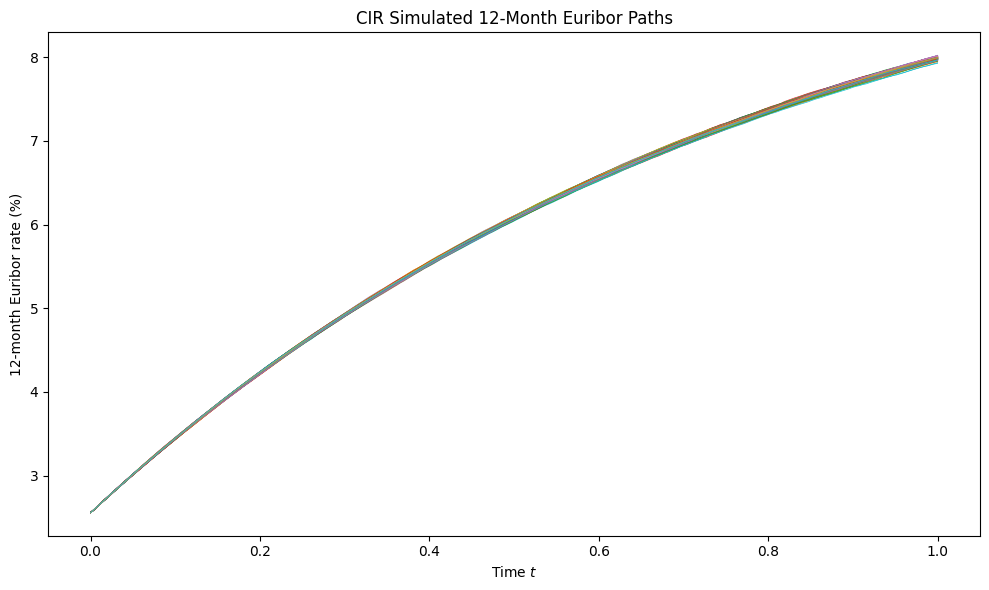

In [51]:
# Plot the first 200 paths - drawing 100,000 paths are too much!
plt.figure(figsize=(10, 6))
for j in range(200):
    plt.plot(t, rates_cir[:, j] * 100, linewidth=0.5)
plt.xlabel("Time $t$")
plt.ylabel("12-month Euribor rate (%)")
plt.title("CIR Simulated 12-Month Euribor Paths")
plt.tight_layout()
plt.show()

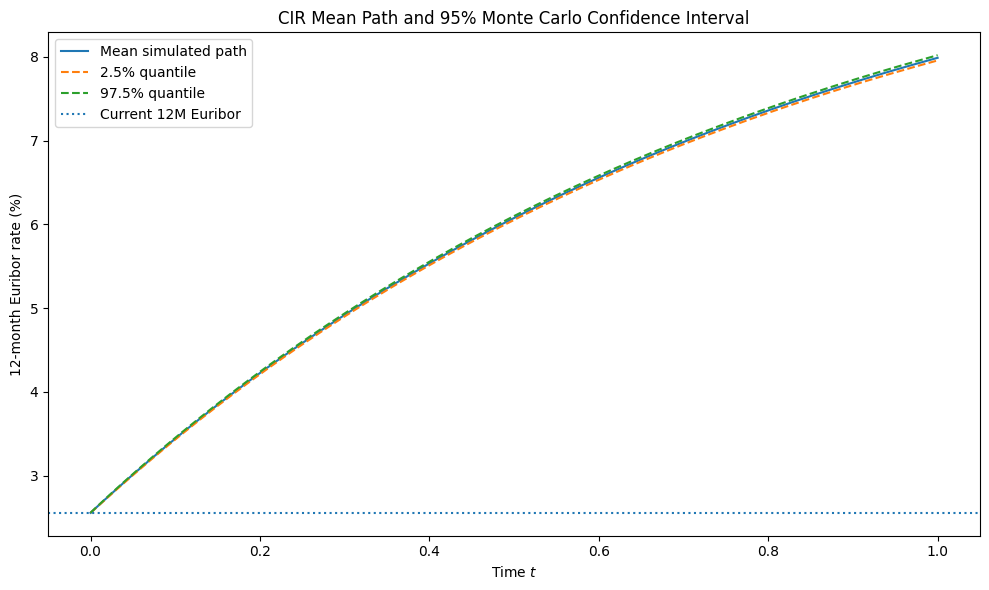

In [52]:
# Plot the graph with 95% confidence interval
mean_path = np.mean(rates_cir, axis=1)
lower_path = np.quantile(rates_cir, lower_q, axis=1)
upper_path = np.quantile(rates_cir, upper_q, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(t, mean_path * 100, label="Mean simulated path")
plt.plot(t, lower_path * 100, "--", label="2.5% quantile")
plt.plot(t, upper_path * 100, "--", label="97.5% quantile")
plt.axhline(r0 * 100, linestyle=":", label="Current 12M Euribor")
plt.xlabel("Time $t$")
plt.ylabel("12-month Euribor rate (%)")
plt.title("CIR Mean Path and 95% Monte Carlo Confidence Interval")
plt.legend()
plt.tight_layout()
plt.show()

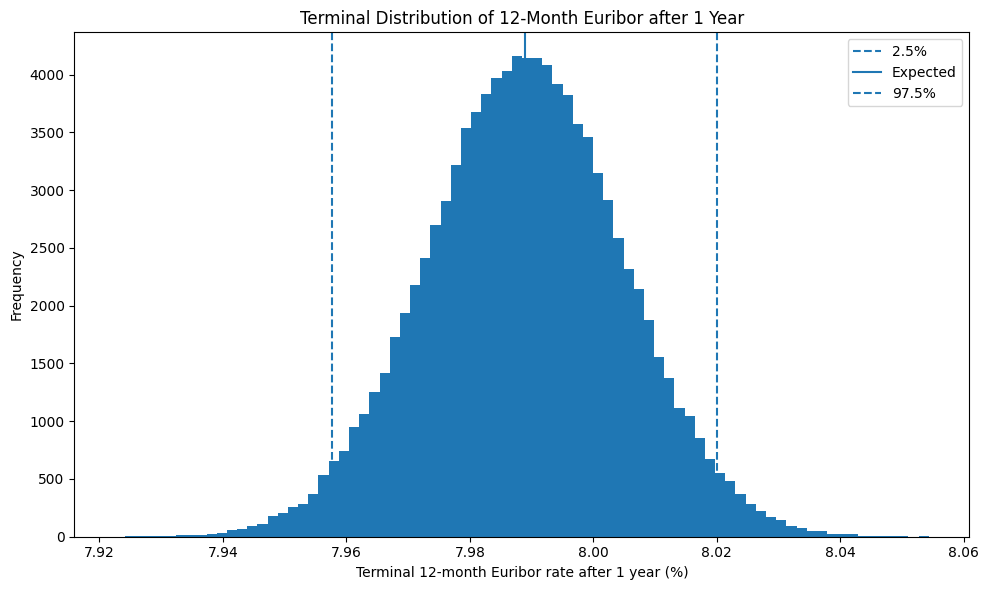

In [53]:
# The histogram plot similar to Module 4, Lesson 2
plt.figure(figsize=(10, 6))
plt.hist(terminal_rates * 100, bins=80)
plt.axvline(lower_bound * 100, linestyle="--", label="2.5%")
plt.axvline(expected_value * 100, linestyle="-", label="Expected")
plt.axvline(upper_bound * 100, linestyle="--", label="97.5%")
plt.xlabel("Terminal 12-month Euribor rate after 1 year (%)")
plt.ylabel("Frequency")
plt.title("Terminal Distribution of 12-Month Euribor after 1 Year")
plt.legend()
plt.tight_layout()
plt.show()

## Report of Step 3b - Team
We selected 95% confidence level. Based on our Monte Carlo simulation, the 12-month Euribor is expected to fall in the range 7.9577% and 8.0200%. The overall simulated min and max are 7.9225% and 8.0543%. We believe 95% is a good confidence level to predice the 1-year interest rate. Note that, it is quite narrow in our simulation.

The expected value of our simulation is 7.989%. Comparing to the current 1-year rate at 2.556%, the simulated one is much higher. The model is prediciting an increase of 5.433%. i.e. 543.3 basis points higher. We believe this high expected value is due to the calibrated CIR parmeter having a high long-term average rate at 10.26% and the relatively fast mean reversion at 1.2228. Since the current 1-year rate is far below the calibrated one, the CIR process tries to pull the rates up strongly in a year.

In terms of pricing, floating-rate products using the current 1-year rate will be repriced upward. It means the borrowers will face higher interest payment and the bank will receive higher floating-rate income. However, higher rates also increases credit risks because now the borrowers are under a higher pressures to repay the depts.

For fixed-rate products, existing one will now become less attractive compared to the new one which is going to be having a higher rate. So, the price of existing fixed-rate products will drop.

### Step 4 - Team
#### N/A - Step 4 is the writeup and organization stuff

In [58]:
# THE END - Some outline problem in printing colab
# Adjust the space below to make sure everything is printed
print("""











































































































THE END!
""")













































































































THE END!

